# Monte Carlo vs Temporal Difference Learning

Classical Reinforcement Learning involves two core problems: the prediction and the control. Prediction involves estimating the value function of a current policy, and control involves optimizing a policy (and is thus dependent on prediction as you need an evaluation method to quantitatively improve). 

The goal of this experiment is to compare Monte Carlo and Td(0) algorithms on the CliffWalking Environment. 

Firstly, First Visit Monte Carlo prediction and TD(0) prediction algorithms will be implemented for estimating $V^{\pi}$(S), and some analysis will be made on these algorithms. 
Next the controlled versions will be implemented: Monte Carlo control and SARSA (which is an on policy TD(0) control). Then we will analyse them and answer some interesting questions related to them. 

In [17]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from agents.algorithms import TD0Prediction, FirstVisitMCPrediction
from agents.algorithms import TabularSarsa, MonteCarloControl
from utils.runner import train_agent, train_mc_agent, run_episode, run_mc_episode

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


I would firstly like to remark following the introduction that in the first experiment (continuous case), the prediction and the control were interconnected and not explicitly pointed out. The prediciton was the process updating the weights through linear approximation (and thus estimates the value function), and the control was the updation of the policy after prediction (the argmax equation). 

In this case, the prediciton and the control is explicit.

You may find the specific algorithms in the respective files. We are now going to compare the algorithms. 

Generating 'True V(s)' baseline (this might take a few seconds)...


MC Training Episodes: 100%|██████████| 2000/2000 [01:46<00:00, 18.82it/s, Return=-413429]



--- Running TD(0) Prediction ---
--- Running First-Visit MC Prediction ---

--- Running Sensitivity Analysis for alpha ---


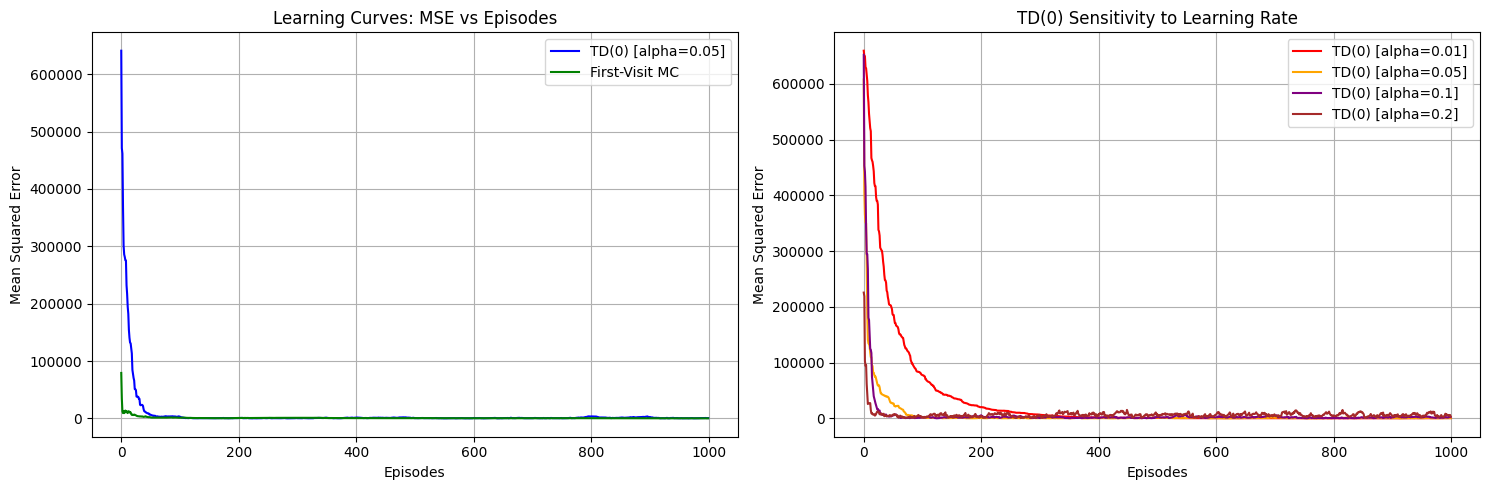

In [21]:
env = gym.make("CliffWalking-v1")

num_states = env.observation_space.n
num_actions = env.action_space.n
gamma = 0.99
episodes_pred = 1000

print("Generating 'True V(s)' baseline (this might take a few seconds)...")
baseline_agent = FirstVisitMCPrediction(num_states, num_actions, gamma)
_ = train_mc_agent(env, baseline_agent, 2000) 
true_v = baseline_agent.v_table.copy()

def train_and_track_mse(env, agent, true_v, num_episodes, is_mc=False):
    mse_history = []
    for ep in range(num_episodes):
        if is_mc:
            trajectory, _ = run_mc_episode(env, agent)
            agent.update(trajectory)
        else:
            _ = run_episode(env, agent)
        
        mse = np.mean((agent.v_table - true_v) ** 2)
        mse_history.append(mse)
    return mse_history

print("\n--- Running TD(0) Prediction ---")
td0_agent = TD0Prediction(num_states, num_actions, alpha=0.05, gamma=gamma)
td0_mse = train_and_track_mse(env, td0_agent, true_v, episodes_pred, is_mc=False)

print("--- Running First-Visit MC Prediction ---")
mc_pred_agent = FirstVisitMCPrediction(num_states, num_actions, gamma)
mc_mse = train_and_track_mse(env, mc_pred_agent, true_v, episodes_pred, is_mc=True)

print("\n--- Running Sensitivity Analysis for alpha ---")
alphas_to_test = [0.01, 0.05, 0.1, 0.2]
td_alpha_results = {}

for a in alphas_to_test:
    temp_agent = TD0Prediction(num_states, num_actions, alpha=a, gamma=gamma)
    td_alpha_results[a] = train_and_track_mse(env, temp_agent, true_v, episodes_pred, is_mc=False)

env.close()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(td0_mse, label='TD(0) [alpha=0.05]', color='blue')
axes[0].plot(mc_mse, label='First-Visit MC', color='green')
axes[0].set_xlabel('Episodes')
axes[0].set_ylabel('Mean Squared Error')
axes[0].set_title('Learning Curves: MSE vs Episodes')
axes[0].legend()
axes[0].grid(True)

colors = ['red', 'orange', 'purple', 'brown']
for (a, mse_hist), color in zip(td_alpha_results.items(), colors):
    axes[1].plot(mse_hist, label=f'TD(0) [alpha={a}]', color=color)
axes[1].set_xlabel('Episodes')
axes[1].set_ylabel('Mean Squared Error')
axes[1].set_title('TD(0) Sensitivity to Learning Rate')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Let us zoom in;. 

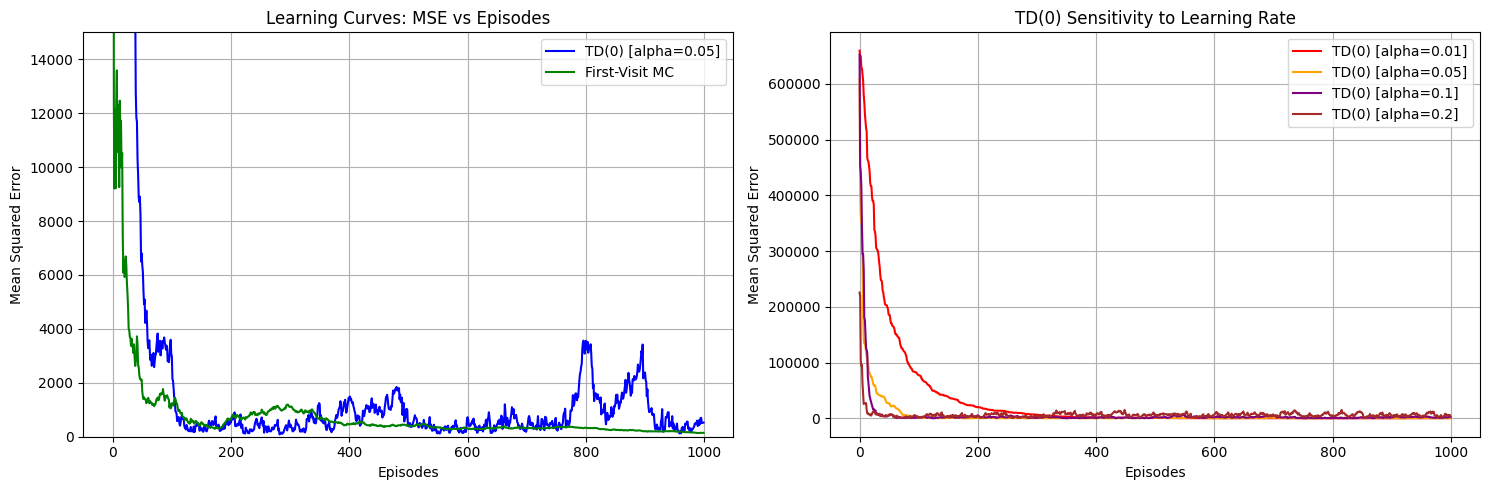

In [29]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(td0_mse, label='TD(0) [alpha=0.05]', color='blue')
axes[0].plot(mc_mse, label='First-Visit MC', color='green')
axes[0].set_xlabel('Episodes')
axes[0].set_ylabel('Mean Squared Error')
axes[0].set_title('Learning Curves: MSE vs Episodes')
axes[0].legend()
axes[0].grid(True)
axes[0].set_ylim(0, 15000) #zoom in. 
colors = ['red', 'orange', 'purple', 'brown']
for (a, mse_hist), color in zip(td_alpha_results.items(), colors):
    axes[1].plot(mse_hist, label=f'TD(0) [alpha={a}]', color=color)
axes[1].set_xlabel('Episodes')
axes[1].set_ylabel('Mean Squared Error')
axes[1].set_title('TD(0) Sensitivity to Learning Rate')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


You generally expect Monte Carlo to have higher variance. This is particularly because it observes an entire episode before updating the values, and hence its return prediciton is affected by a long sequence of random events (mathematically, they all add up to give $G_t$). You also thus expect a TD(0) algorithm to converge faster. 

However, that is clearly not the case above. This is specifically because I have decreased the learning rate of Monte Carlo with the steps, thus reducing the variance, and leading to faster convergence (Not a lot of variance is observed in the process as time progresses). The MSE reduces nicely compared to TD(0) because Monte Carlo acts as an unbiased estimator. 

The bias and Variance tradeoff can also be observed in the TD(0) sensitivity to learning rate. As the learning rate increases, the mean squared error drops more rapidly, but the variance increases making it harder to converge. 

You can argue in the opposite direction: in the creation of an unbiased estimator, you must take into account the entire sequence of actions. And in creating an estimator with very low variance, you must not look too ahead in the future. This motivated the construction of Monte Carlo and TD(0) prediction algorithms the way they are. 

In a more chaotic environment (environments with high variance returns), you would prefer to use TD(0) as it is more difficult for the alternative (Monte Carlo) to converge. 

--- Training Tabular SARSA ---


Training Episodes: 100%|██████████| 1000/1000 [00:00<00:00, 1632.29it/s, Return=-17, Eps=0.01]



--- Training MC Control ---


MC Training Episodes: 100%|██████████| 1000/1000 [01:10<00:00, 14.10it/s, Return=-21, Eps=0.01]   


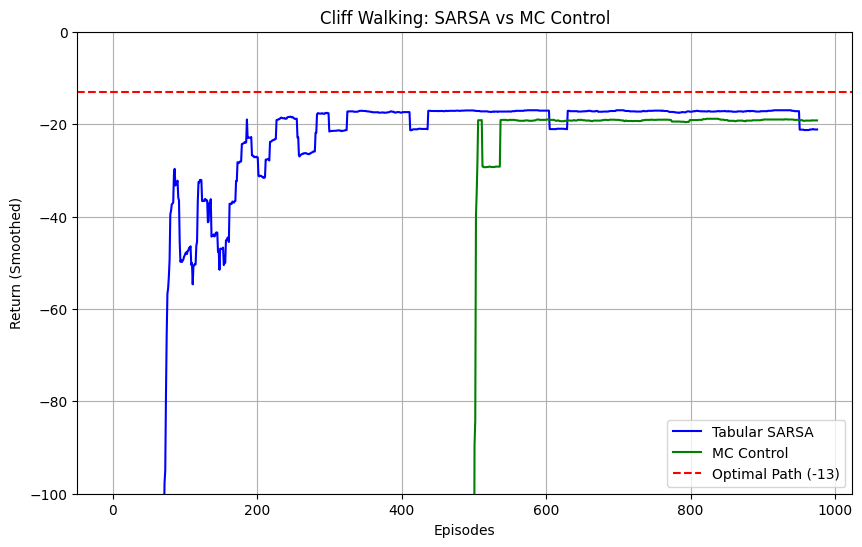

In [22]:
alpha_sarsa = 0.1
epsilon_start = 1.0
episodes_control = 1000

sarsa_agent = TabularSarsa(num_states, num_actions, alpha_sarsa, gamma, epsilon_start)
mc_control_agent = MonteCarloControl(num_states, num_actions, gamma, epsilon_start)

print("--- Training Tabular SARSA ---")
sarsa_returns = train_agent(env, sarsa_agent, episodes_control, epsilon_decay=0.99)

print("\n--- Training MC Control ---")
mc_returns = train_mc_agent(env, mc_control_agent, episodes_control, epsilon_decay=0.99)

env.close()

plt.figure(figsize=(10, 6))
window = 25
plt.plot(np.convolve(sarsa_returns, np.ones(window)/window, mode='valid'), label='Tabular SARSA', color='blue')
plt.plot(np.convolve(mc_returns, np.ones(window)/window, mode='valid'), label='MC Control', color='green')
plt.axhline(y=-13, color='r', linestyle='--', label='Optimal Path (-13)')
plt.ylim(-100, 0)
plt.xlabel('Episodes')
plt.ylabel('Return (Smoothed)')
plt.title('Cliff Walking: SARSA vs MC Control')
plt.legend()
plt.grid(True)
plt.show()

Below, you may observe the performance of both the agents. 

In [27]:
print("Spawning inline test environment...")
render_env = gym.make("CliffWalking-v1", render_mode="rgb_array")
fig, ax = plt.subplots(figsize=(8, 4))

def watch_cliff_agent(agent, agent_name):
    agent.epsilon = 0.0
    state, _ = render_env.reset()
    done = False
    
    print(f"--- Now rendering {agent_name} ---")
    
    while not done:
        action = agent.act(state)
        state, _, terminated, truncated, _ = render_env.step(action)
        done = terminated or truncated
        
        frame = render_env.render()
        ax.clear()
        ax.imshow(frame)
        ax.axis('off')
        display(fig)
        clear_output(wait=True)

watch_cliff_agent(sarsa_agent, "Tabular SARSA")
watch_cliff_agent(mc_control_agent, "MC Control")

render_env.close()
plt.close(fig)
print("Cliff Walking evaluation complete!")

Cliff Walking evaluation complete!


## Certain Theoretical Explorations

The below are three claims that I will justify (or disprove), they are nice to think about as explorations: 

1) TD(0) performs bootstrapping while Monte Carlo does not. 

In the context of Reinforcement Learning, Bootstrapping is updating a value estimate based on another value estimate. 

Let us look at the updation rules for both Monte Carlo and TD(0) learning algorithms respectively: 

$$
 V(S_t) \leftarrow V(S_t) + \alpha(G_t - V(S_t))
$$

$$
V(S_t) \leftarrow V(S_t) + \alpha(R_{t+1} + \gamma V(S_{t+1}) - V(S_t))
$$

It is clear that the latter is dependent on another value estimate, while the former relies solely on itself. $G_t$ is the expected return. 

2) TD updates online. 

It is clear fro the equations above that Monte Carlo requires the entire episode to be over, to be able to calculate $G_t$. However, TD has no such constraints, and only needs to look one step into the future. 

3) TD is approximates dynamic programming!

Dynamic Programming is just efficient recurssion. TD(0) updating rule is also a recursive rule. And you use memoization to store values in a table, which saves a lot of compute time (this is the part that makes it a dynamic programming problem). However, it is not exactly dynamic programming (and hence, "approximates" it) since it is online. It cannot go through every state in order, and is an online algorithm. 

4) If $\pi_{i}$ and $\pi_{i+1}$ are two greedy policies you get from value iterations, is it true that $\pi_{i} \leq \pi_{i+1}$? 

No, this claim is false. Value iteration guarantees the monotonicity of the value functions, but not the underlying policies. 

Here is a simple counterexample: Consider the discount factor to be $\gamma = 1$ (So no discounting). Initial State is S. If you go left, you get $+2$ reward, and the game terminates. Else you can go right for no reward and reach state $A$. From state $A$, you can only go forward with reward $+10$ to state $B$, and from there, you can only move forward to get reward $-100$ and then the game terminates. You initialize the value function at all states to be $0$. In the first iteration $V(A) = 2, V(B) = -100$. Also, $\pi_1$ is going left. In the second iteration, the policy gets tricked into going right because the $Q$ function is greater in moving right, but the true return of this policy is much lesser. 